In [6]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore') # To ignore any warnings during execution

In [7]:
# reading the data
df = pd.read_csv('/content/titanic.csv')

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Problem Statement: The Titanic dataset is a classic binary classification problem used in machine learning and data analysis. The goal is to perform Exploratory Data Analysis (EDA) to uncover patterns, detect anomalies, and prepare the data for predictive modeling. Specifically, the target variable is Survived, and the aim is to explore the dataset to understand what factors might have influenced survival during the Titanic disaster.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 1. PassengerId: A unique identifier for each passenger on the Titanic.
# 2. Survived: A binary variable indicating whether the passenger survived (1) or did not survive (0) the Titanic disaster.
# 3. Pclass: The passenger's ticket class, which is a proxy for socio-economic status. It has three levels: 1st class (1), 2nd class (2), and 3rd class (3).
# 4. Name: The full name of the passenger, which may include titles such as Mr., Mrs., Miss, etc.
# 5. Sex: The gender of the passenger, typically recorded as 'male' or 'female'.
# 6. Age: The age of the passenger in years. This column may contain missing values.
# 7. SibSp: The number of siblings and spouses the passenger had aboard the Titanic.
# 8. Parch: The number of parents and children the passenger had aboard the Titanic.
# 9. Ticket: The ticket number assigned to the passenger. This may include both numeric and alphanumeric values.
# 10. Fare: The fare paid by the passenger for their ticket, recorded in British pounds.
# 11. Cabin: The cabin number assigned to the passenger. This column may contain missing values and is often used to infer the passenger's location on the ship.
# 12. Embarked: The port where the passenger boarded the Titanic. It has three possible values: C (Cherbourg), Q (Queenstown), and S (Southampton).

In [11]:
# Insights from the above code:
# 1. The dataset contains 891 rows and 12 columns.
# 2. Age column has missing values.
# 3. Cabin column has a significant number of missing values.
# 4. The Embarked column has 2 missing values.

In [12]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [13]:
# Insights from the summary statistics:
# 1. On an average 0.383838	of the passengers survived.
# 2. The average age of passengers is 29.699118 years indicating that most passengers were young. The minimum age is 0.42, which
# likely represents an infant, and the maximum age is 80, indicating that there were elderly passengers as well.
# 3. The fare paid by passengers varies significantly, with a mean fare of 32.204208. Some passengers paid very high fares,
# indicating the presence of luxury accommodations. And some passengers paid 0 fare, indicating they might have been crew members or had other arrangements.
# 4. The majority of passengers embarked from Southampton (S).

In [14]:
# collecting categorical columns

cat_cols= ['Survived', 'Pclass','Sex', 'SibSp', 'Parch', 'Cabin', 'Embarked']
cat_cols

['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Cabin', 'Embarked']

In [16]:
# Lets find the unique values in each categorical column
for col in cat_cols:
    print(f"Unique values in {col}: {df[col].unique()}","\n")

Unique values in Survived: [0 1] 

Unique values in Pclass: [3 1 2] 

Unique values in Sex: ['male' 'female'] 

Unique values in SibSp: [1 0 3 4 2 5 8] 

Unique values in Parch: [0 1 2 5 3 4 6] 

Unique values in Cabin: [nan 'C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6' 'C23 C25 C27' 'B78' 'D33'
 'B30' 'C52' 'B28' 'C83' 'F33' 'F G73' 'E31' 'A5' 'D10 D12' 'D26' 'C110'
 'B58 B60' 'E101' 'F E69' 'D47' 'B86' 'F2' 'C2' 'E33' 'B19' 'A7' 'C49'
 'F4' 'A32' 'B4' 'B80' 'A31' 'D36' 'D15' 'C93' 'C78' 'D35' 'C87' 'B77'
 'E67' 'B94' 'C125' 'C99' 'C118' 'D7' 'A19' 'B49' 'D' 'C22 C26' 'C106'
 'C65' 'E36' 'C54' 'B57 B59 B63 B66' 'C7' 'E34' 'C32' 'B18' 'C124' 'C91'
 'E40' 'T' 'C128' 'D37' 'B35' 'E50' 'C82' 'B96 B98' 'E10' 'E44' 'A34'
 'C104' 'C111' 'C92' 'E38' 'D21' 'E12' 'E63' 'A14' 'B37' 'C30' 'D20' 'B79'
 'E25' 'D46' 'B73' 'C95' 'B38' 'B39' 'B22' 'C86' 'C70' 'A16' 'C101' 'C68'
 'A10' 'E68' 'B41' 'A20' 'D19' 'D50' 'D9' 'A23' 'B50' 'A26' 'D48' 'E58'
 'C126' 'B71' 'B51 B53 B55' 'D49' 'B5' 'B20' 'F G63' 'C62

In [19]:
# Lets find the value counts for each categorical column
for col in cat_cols:
    print(df[col].value_counts())
    print(".."*30)
    print(df[col].value_counts(normalize=True)*100)  # Display the percentage of each category
    print("=="*30)


Survived
0    549
1    342
Name: count, dtype: int64
............................................................
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
............................................................
Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64
Sex
male      577
female    314
Name: count, dtype: int64
............................................................
Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
............................................................
SibSp
0    68.237935
1    23.456790
2     3.142536
4     2.020202
3     1.795735
8     0.785634
5     0.561167
Name: proportion, dtype: float64
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
.................

In [20]:
# Insights from the above code:
# 1. The majority of passengers did not survive (61.6% did not survive, 38.4% survived).
# 2. Most passengers were in the 3rd class (55.1%), followed by 1st class (24.2%) and 2nd class (20.7%).
# 3. The majority of passengers were male (64.8%), with females making up 35.2% of the passengers.
# 4. Most passengers had no siblings or spouses aboard (60.0% had 0 siblings/spouses).
# 5. Most passengers had no parents or children aboard (78.2% had 0 parents/children).
# 6. The Cabin column has many missing values, indicating that many passengers did not have a cabin assigned.
# 7. The majority of passengers embarked from Southampton (72.0%), followed by Cherbourg (18.2%) and Queenstown (9.8%).

In [21]:
# Lets find the missing values in each column of the DataFrame
df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [23]:
df.shape

(891, 12)

In [ ]:
# Insights from the above code:
# 1. Cabin has the highest number of missing values (77.1%). Its better to drop this column as it has too many missing values.
# 2. Age has 177 missing values (19.9%). We can fill these missing values with the mean or median age.
# 3. Embarked has 2 missing values (0.2%). We can fill these missing values with the mode of the column.

In [24]:
# Dropping the Cabin column
df.drop(columns=['Cabin'], inplace=True)

# Lets check the number of missing values in the DataFrame again
df.isnull().sum().sort_values(ascending=False)

,0
Age,177
Embarked,2
PassengerId,0
Pclass,0
Survived,0
Sex,0
Name,0
SibSp,0
Parch,0
Ticket,0


In [25]:
df.Embarked.mode()  # Find the mode of the Embarked column

,Embarked
0,S


In [26]:
type(df.Embarked.mode())

pandas.core.series.Series

In [27]:
df.Embarked.mode()[0]  # Get the mode of the Embarked column

'S'

In [28]:
# We see that, most passengers embarked from Southampton (S).
# Therefore, we can fill the missing values in the Embarked column with 'S'.
df['Embarked'].fillna(df.Embarked.mode()[0], inplace=True)
# or
# df['Embarked'].fillna('S', inplace=True)

# Lets check the number of missing values in the DataFrame again
df.isnull().sum().sort_values(ascending=False)

,0
Age,177
Survived,0
PassengerId,0
Pclass,0
Name,0
Sex,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [29]:
# Strategy to fill the missing values in the numerical columns
# 1. If the column is normally distributed, fill the missing values with the mean of the column.
# 2. If the column is skewed, fill the missing values with the median of the column.

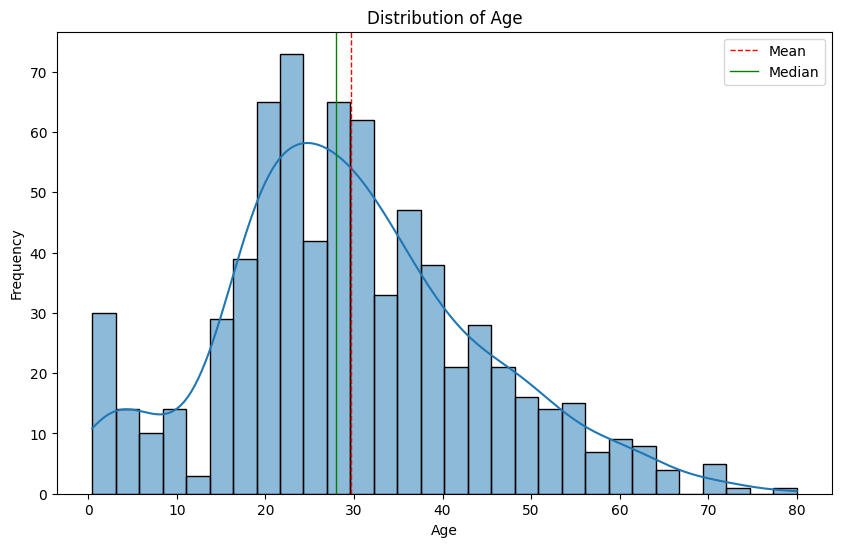

In [30]:
# Lets plot the distribution of the Age column to check if it is normally distributed or skewed
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.axvline(df['Age'].mean(), color='r', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(df['Age'].median(), color='g', linestyle='solid', linewidth=1, label='Median')
plt.legend()
plt.show()

In [31]:
df.Age.skew() # Check the skewness of the Age column

np.float64(0.38910778230082704)

In [32]:
# If this value is between:
# -0.5 and 0.5, the distribution of the value is almost symmetrical
# -1 and -0.5, the data is negatively skewed, and if it is between 0.5 to 1, the data is positively skewed. The skewness is moderate.
# If the skewness is lower than -1 (negatively skewed) or greater than 1 (positively skewed), the data is highly skewed.


In [33]:
# Since the skewness of the Age column is 0.389, which is between -0.5 and 0.5, we can fill the missing values with the mean of the column.
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Lets check the number of missing values in the DataFrame again
df.isnull().sum().sort_values(ascending=False)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [34]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C


In [35]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [36]:
#Feature Engineering

In [37]:
#We can create a new feature called FamilySize by combining SibSp and Parch.
# FamilySize = SibSp + Parch + 1  # +1 for the passenger themselves

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S,1
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S,1
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S,5
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S,3
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C,2


In [38]:
# Now lets engineer a column "isAlone" which indicates if the passenger is alone or not
df['isAlone'] = df['FamilySize'].apply(lambda x: 1 if x == 1 else 0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,isAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1


In [39]:
df['isAlone'].value_counts()

,count
isAlone,
1,537
0,354


In [40]:
df['isAlone'].value_counts(normalize=True) * 100

,proportion
isAlone,
1,60.26936
0,39.73064


In [ ]:
# 1. 60.26% of the passengers were alone, while 39.74% had family members aboard.
# 2. This feature can help in understanding the survival rate of passengers who were alone versus those who had family members aboard.
# This can be useful in analyzing the impact of family size on survival rates.

In [41]:
#Name:
# We can extract the title from the Name column and create a new feature called Title.

df['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())  # Extract the title from the Name column
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,isAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr


In [42]:
# Lets find the unique titles in the Title column
df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess',
       'Jonkheer'], dtype=object)

In [43]:
# value_counts on the Title column
df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [44]:
#Lets merge all uncommon titles into Mr, Miss, Mrs, Master
# Logic:
# 1. If the title is 'Dr' or 'Rev' or 'Major' or 'Col' or 'Capt' or 'Don' or 'Sir' or 'Jonkheer', then we will replace it with 'Mr' (assuming they are male)
# 2. If the title is 'Mlle' or 'Ms', then we will replace it with 'Miss'
# 3. If the title is 'Mme' or 'the Countess' or 'Lady', then we will replace it with 'Mrs'
def merge_titles(title):
    if title in ['Dr', 'Rev', 'Major', 'Col', 'Capt', 'Don', 'Sir', 'Jonkheer']:
        return 'Mr'
    elif title in ['Mlle', 'Ms']:
        return 'Miss'
    elif title in ['Mme', 'the Countess', 'Lady']:
        return 'Mrs'
    else:
        return title

df['Title'] = df['Title'].apply(merge_titles)
df['Title'].value_counts()  # Display the value counts of the Title column after merging

,count
Title,
Mr,538
Miss,185
Mrs,128
Master,40


In [45]:
#Age:
# We can create a new feature called AgeGroup by categorizing the Age into different groups. with the help of binning

def age_group(age):
    if age < 12:
        return 'Child'
    elif 12 <= age < 20:
        return 'Teenager'
    elif 20 <= age < 35:
        return 'Young Adult'
    elif 35 <= age < 60:
        return 'Adult'
    else:
        return 'Senior'
df['AgeGroup'] = df['Age'].apply(age_group)
df['AgeGroup'].value_counts()



,count
AgeGroup,
Young Adult,492
Adult,209
Teenager,96
Child,68
Senior,26


In [46]:
df["Survived"].value_counts()  # Display the value counts of the Survived column
# Insights from the above code:
# Majority of the passengers did not survive (61.6% did not survive, 38.4% survived).

,count
Survived,
0,549
1,342


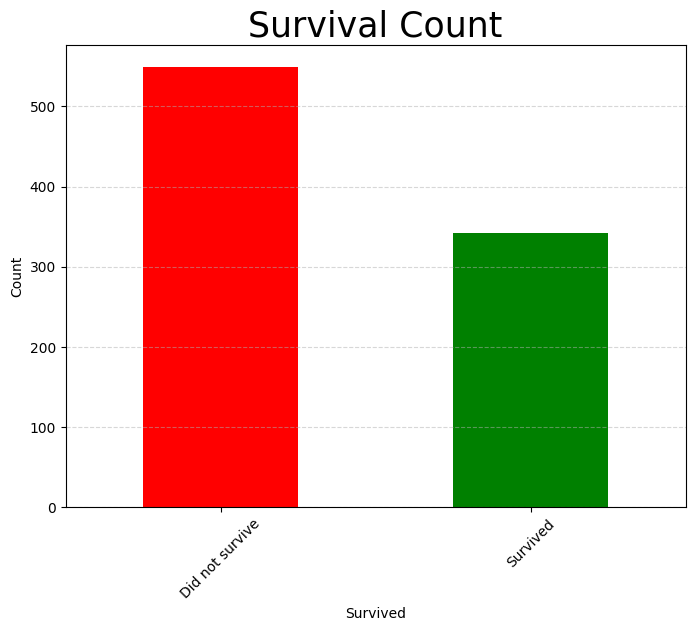

In [47]:
df["Survived"].value_counts().plot(kind='bar', figsize=(8, 6), color=['red', 'green'])
plt.title('Survival Count', size=25)
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Did not survive', 'Survived'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

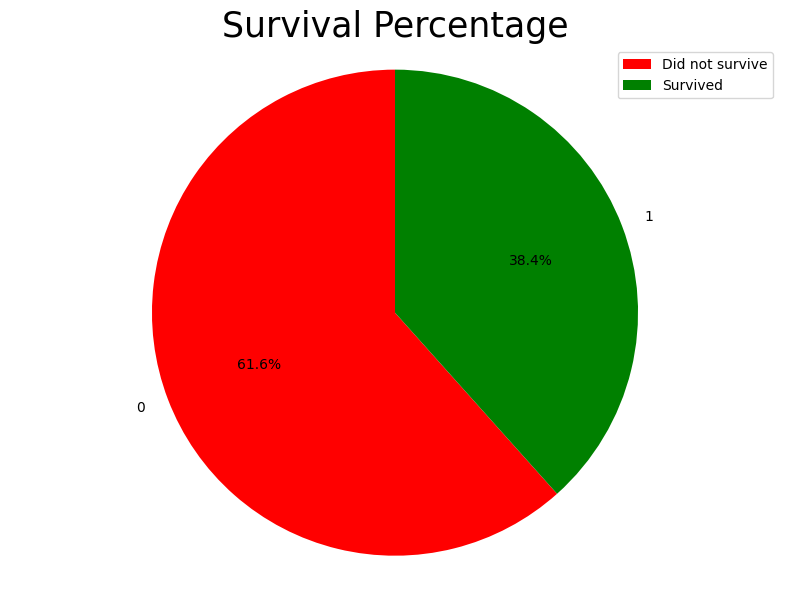

In [48]:
df["Survived"].value_counts().plot(kind="pie", figsize=(8, 6), autopct='%1.1f%%', startangle=90, colors=['red', 'green'])
plt.title('Survival Percentage', size=25)
plt.ylabel('')  # Hide the y-label for better aesthetics
plt.legend(labels=['Did not survive', 'Survived'], loc='upper right')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is a circle.
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show()  # Show the plot

In [49]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,isAlone,Title,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr,Adult


In [50]:
# Survival rate by Pclass
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [ ]:
# 1. The survival rate for passengers in 1st class is 62.96%, which is significantly higher than the survival rates for
# passengers in 2nd class (47.28%) and 3rd class (24.24%).
# 2. This indicates that passengers in 1st class had a higher chance of survival compared to those in 2nd and 3rd class.

In [51]:
# Survival rate by Sex
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [ ]:
# 1. The survival of Female passengers is significantly higher (74.2%) compared to Male passengers (18.9%).
# 2. This indicates that Female passengers had a much higher chance of survival compared to Male passengers.

In [52]:
# Survival rate by Embarked
df.groupby('Embarked')['Survived'].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.339009


In [ ]:
# 1. The survival rate for passengers who embarked from Cherbourg (C) is the highest at 55.4%, followed by those who embarked from
# Southampton (S) at 33.7%, and Queenstown (Q) at 23.8%.
# 2. This indicates that passengers who embarked from Cherbourg had a higher chance of survival compared to those who embarked from Southampton and Queenstown.

In [53]:
# Survival rate by Title
df.groupby('Title')['Survived'].mean()

,Survived
Title,
Master,0.575000
Miss,0.702703
Mr,0.161710
Mrs,0.796875


In [ ]:
# 1. The survival rate for passengers with the title "Master" is the highest at 57.1%, followed by "Miss" at 69.4%, and "Mrs" at 79.0%.
# 2. The survival rate for passengers with the title "Mr" is the lowest at 18.9%.
# 3. This indicates that passengers with the title "Master", "Miss", and "Mrs" had a higher chance of survival compared to those with the title "Mr".

In [54]:
#Fare:
# We can create a new feature called FarePerPerson by dividing the Fare by the FamilySize.
df.Fare.describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [55]:
# Lets find the passengers who paid 0 Fare
df[df['Fare'] == 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,isAlone,Title,AgeGroup
179,180,0,3,"Leonard, Mr. Lionel",male,36.000000,0,0,LINE,0.0,S,1,1,Mr,Adult
263,264,0,1,"Harrison, Mr. William",male,40.000000,0,0,112059,0.0,S,1,1,Mr,Adult
271,272,1,3,"Tornquist, Mr. William Henry",male,25.000000,0,0,LINE,0.0,S,1,1,Mr,Young Adult
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,29.699118,0,0,239853,0.0,S,1,1,Mr,Young Adult
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.000000,0,0,LINE,0.0,S,1,1,Mr,Teenager
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,29.699118,0,0,239853,0.0,S,1,1,Mr,Young Adult
466,467,0,2,"Campbell, Mr. William",male,29.699118,0,0,239853,0.0,S,1,1,Mr,Young Adult
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,29.699118,0,0,239854,0.0,S,1,1,Mr,Young Adult
597,598,0,3,"Johnson, Mr. Alfred",male,49.000000,0,0,LINE,0.0,S,1,1,Mr,Adult
633,634,0,1,"Parr, Mr. William Henry Marsh",male,29.699118,0,0,112052,0.0,S,1,1,Mr,Young Adult


In [56]:
# Insights from the above code:
# 1. The majority of passengers who paid 0 Fare are crew members, as indicated by the "Crew" title in the Name column.
# 2. The crew members are not included in the survival analysis, as they were not passengers.

# Lets create a new feature called "isCrewMember" to indicate if the passenger is a crew member or not
df['isCrewMember'] = df['Fare'].apply(lambda x: 1 if x == 0 else 0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,isAlone,Title,AgeGroup,isCrewMember
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr,Young Adult,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs,Adult,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss,Young Adult,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs,Adult,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr,Adult,0


In [57]:
df["isCrewMember"].value_counts()

,count
isCrewMember,
0,876
1,15


In [58]:
# 15 crew members are present in the dataset, which is a small percentage of the total passengers.

In [59]:
#Solo travelers vs family survival
# Survival count by isAlone
df.groupby('isAlone')['Survived'].value_counts()

# Survival rate
df.groupby('isAlone')['Survived'].mean()

,Survived
isAlone,
0,0.505650
1,0.303538


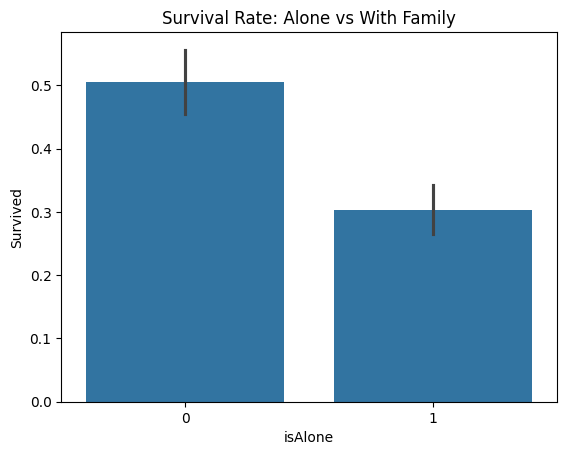

In [60]:
sns.barplot(x='isAlone', y='Survived', data=df)
plt.title('Survival Rate: Alone vs With Family')
plt.show()

In [61]:
#Survival rate across different age groups
# Create age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 20, 40, 60, 100],
                       labels=['Child', 'Teen', 'Adult', 'Mid-age', 'Senior'])

# Survival rate by age group
df.groupby('AgeGroup')['Survived'].mean()

,Survived
AgeGroup,
Child,0.579710
Teen,0.381818
Adult,0.364769
Mid-age,0.390625
Senior,0.227273


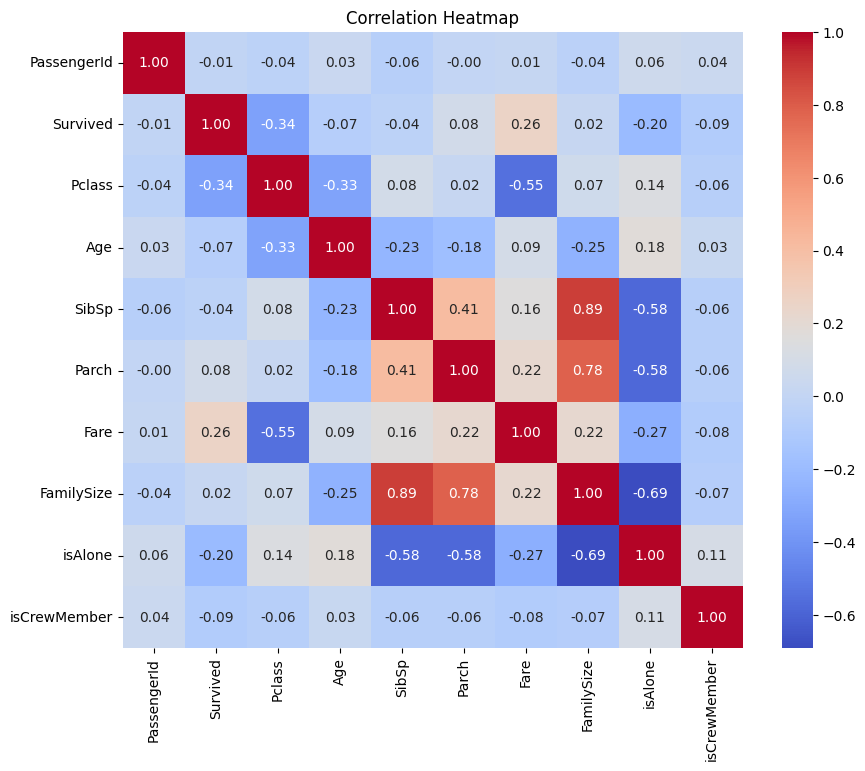

In [62]:
# Select numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

##End of EDA